# Лабораторная работа 5. Итеративные и оптимизационные атаки: PGD, C&W, JSMA

**Курс:** Машинное обучение. Безопасность ИИ-систем

**По материалам лекции 4**

**Формат:** индивидуально или в парах

**Среда:** Python, PyTorch, torchvision

## Цель работы
Закрепить методы построения многошаговых и оптимизационных evasion-атак и научиться сравнивать их по силе, вычислительной стоимости и величине вносимого искажения.

## Результаты обучения
После выполнения работы вы должны уметь:
- реализовывать PGD-атаку с проекцией на $L_\infty$-шар и случайным стартом;
- объяснять формулировку седловой точки (min-max) и её связь с adversarial training;
- реализовывать целевую C&W L2-атаку с заменой переменных через tanh и параметром confidence κ;
- реализовывать JSMA на основе якобиана выхода модели и точечного насыщения признаков;
- сравнивать атаки по Attack Success Rate, норме возмущения и вычислительным затратам.

## Как пользоваться этим ноутбуком
- Ячейки с `# TODO` необходимо заполнить самостоятельно.
- Ячейки с текстом **"Вопрос для отчёта"** требуют письменного ответа в markdown-ячейке ниже.
- Перед сдачей: Kernel → Restart & Run All, ноутбук должен выполняться от начала до конца без ошибок.
- Атаки на MNIST могут занимать заметное время на CPU (особенно JSMA) — рассчитывайте время выполнения заранее.


## 0. Подготовка окружения

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from torchvision import datasets, transforms

RANDOM_STATE = 33
torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device



device(type='cpu')

## Часть I. Данные и базовая модель

**Задание:** загрузите MNIST и обучите небольшую CNN (2 свёрточных слоя + полносвязный классификатор) — эта модель станет целью для всех атак в работе.

In [2]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

transform = transforms.Compose([
    transforms.ToTensor()
])

train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=128,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=256,
    shuffle=False
)


In [3]:
import torch.nn as nn
import torch.nn.functional as F

class SmallCNN(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.conv1 = nn.Conv2d(
            in_channels=1,
            out_channels=32,
            kernel_size=3,
            stride=1,
            padding=1
        )
        
        self.conv2 = nn.Conv2d(
            in_channels=32,
            out_channels=64,
            kernel_size=3,
            stride=1,
            padding=1
        )
        
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        
        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = self.pool(x)
        
        x = F.relu(self.conv2(x))
        x = self.pool(x)
        
        x = torch.flatten(x, start_dim=1)
        
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        
        return x



In [4]:
model = SmallCNN().to(device)

opt = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

crit = nn.CrossEntropyLoss()

epochs = 3

for epoch in range(epochs):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        opt.zero_grad()

        outputs = model(images)
        loss = crit(outputs, labels)

        loss.backward()
        opt.step()

        running_loss += loss.item() * images.size(0)

        predictions = outputs.argmax(dim=1)
        correct += (predictions == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = 100 * correct / total

    print(
        f"Epoch {epoch + 1}/{epochs} | "
        f"Loss: {epoch_loss:.4f} | "
        f"Accuracy: {epoch_acc:.2f}%"
    )

Epoch 1/3 | Loss: 0.2322 | Accuracy: 93.03%
Epoch 2/3 | Loss: 0.0592 | Accuracy: 98.18%
Epoch 3/3 | Loss: 0.0415 | Accuracy: 98.73%


In [5]:
model.eval()

correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        predictions = outputs.argmax(dim=1)

        correct += (predictions == labels).sum().item()
        total += labels.size(0)

clean_accuracy = 100 * correct / total

print(f"Clean accuracy: {clean_accuracy:.2f}%")

Clean accuracy: 98.96%


## Часть II. Projected Gradient Descent (PGD)

### 2.1. Реализация PGD

**Задание:** реализуйте функцию PGD-атаки по формуле

$$x^{t+1} = \Pi_{x+\mathcal{S}}\left(x^t + \alpha \cdot \operatorname{sign}\left(\nabla_x L(\theta, x^t, y)\right)\right)$$

Функция должна:
1. Инициализировать возмущение случайно внутри \$epsilon$-шара (random start).
2. На каждой итерации пересчитывать градиент и делать шаг по знаку градиента.
3. Проецировать (clip) возмущение на \$epsilon$-шар и итоговый пиксель — на диапазон $[0,1]$.

In [6]:
def pgd_attack(model, x, y, epsilon, alpha, num_iter, criterion, randomize=True):
    # Начальное возмущение
    if randomize:
        delta = torch.empty_like(x).uniform_(-epsilon, epsilon)
        delta = torch.clamp(x + delta, 0, 1) - x
    else:
        delta = torch.zeros_like(x)

    delta = delta.detach()

    for _ in range(num_iter):
        delta.requires_grad_(True)

        # Предсказание на возмущённом изображении
        outputs = model(x + delta)

        # Для untargeted-атаки максимизируем loss
        loss = criterion(outputs, y)

        model.zero_grad()

        # Градиент по возмущению
        loss.backward()

        # Шаг в направлении увеличения ошибки
        delta = delta + alpha * delta.grad.sign()

        # Ограничиваем возмущение epsilon-шаром
        delta = torch.clamp(
            delta,
            -epsilon,
            epsilon
        )

        # Ограничиваем итоговое изображение диапазоном [0, 1]
        delta = torch.clamp(
            x + delta,
            0,
            1
        ) - x

        delta = delta.detach()

    return torch.clamp(x + delta, 0, 1)


### 2.2. Визуализация: FGSM vs PGD

**Задание:** реализуйте FGSM (для сравнения), затем на одном тестовом примере постройте adversarial-версии обоими методами при одинаковом \$epsilon$ и визуализируйте результат (3 подграфика: оригинал, FGSM, PGD) с указанием предсказаний модели.

In [7]:
def fgsm_attack(model, x, y, epsilon, criterion):
    # 1. Включаем отслеживание градиента по входным изображениям
    x = x.clone().detach().requires_grad_(True)

    # 2. Прямой проход через модель
    output = model(x)

    # 3. Вычисляем функцию потерь
    loss = criterion(output, y)

    # 4. Обратный проход: считаем градиент loss по x
    model.zero_grad()
    loss.backward()

    # 5. Строим возмущение:
    # epsilon * sign(градиента по входу)
    perturbation = epsilon * x.grad.sign()

    # 6. Добавляем возмущение и ограничиваем значения пикселей [0, 1]
    x_adv = torch.clamp(x + perturbation, 0, 1)

    return x_adv.detach()


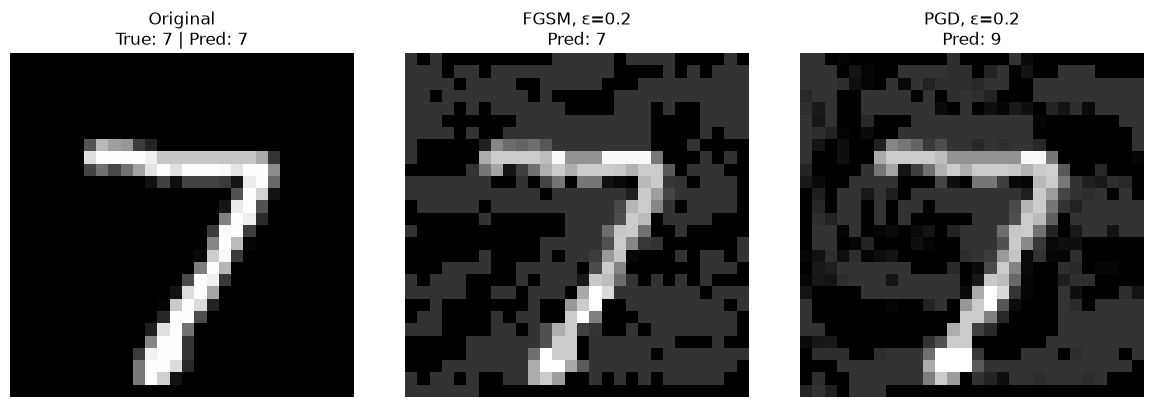

In [8]:
# Выбираем один тестовый пример
images, labels = next(iter(test_loader))

image = images[0:1].to(device)
label = labels[0:1].to(device)

epsilon = 0.2

# FGSM
fgsm_image = fgsm_attack(
    model,
    image,
    label,
    epsilon,
    crit
)

# PGD
pgd_image = pgd_attack(
    model,
    image,
    label,
    epsilon,
    alpha=0.02,
    num_iter=40,
    criterion=crit,
    randomize=True
)

# Получаем предсказания
model.eval()

with torch.no_grad():
    original_pred = model(image).argmax(dim=1).item()
    fgsm_pred = model(fgsm_image).argmax(dim=1).item()
    pgd_pred = model(pgd_image).argmax(dim=1).item()

# Визуализация
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

images_to_show = [
    image,
    fgsm_image,
    pgd_image
]

titles = [
    f"Original\nTrue: {label.item()} | Pred: {original_pred}",
    f"FGSM, ε={epsilon}\nPred: {fgsm_pred}",
    f"PGD, ε={epsilon}\nPred: {pgd_pred}"
]

for ax, img, title in zip(axes, images_to_show, titles):
    ax.imshow(
        img.squeeze().cpu().numpy(),
        cmap="gray"
    )
    ax.set_title(title)
    ax.axis("off")

plt.tight_layout()
plt.show()


**Вопрос для отчёта:** отличаются ли визуально возмущения FGSM и PGD? Какой метод успешнее меняет предсказание модели при одном и том же ε?

_Ваш ответ:_ 

### 2.3. Attack Success Rate: FGSM vs PGD

**Задание:** постройте график зависимости Attack Success Rate от бюджета $\epsilon \in \{0, 0.02, 0.05, 0.1, 0.15, 0.2, 0.3\}$ для FGSM и PGD (20 итераций) на одном графике.

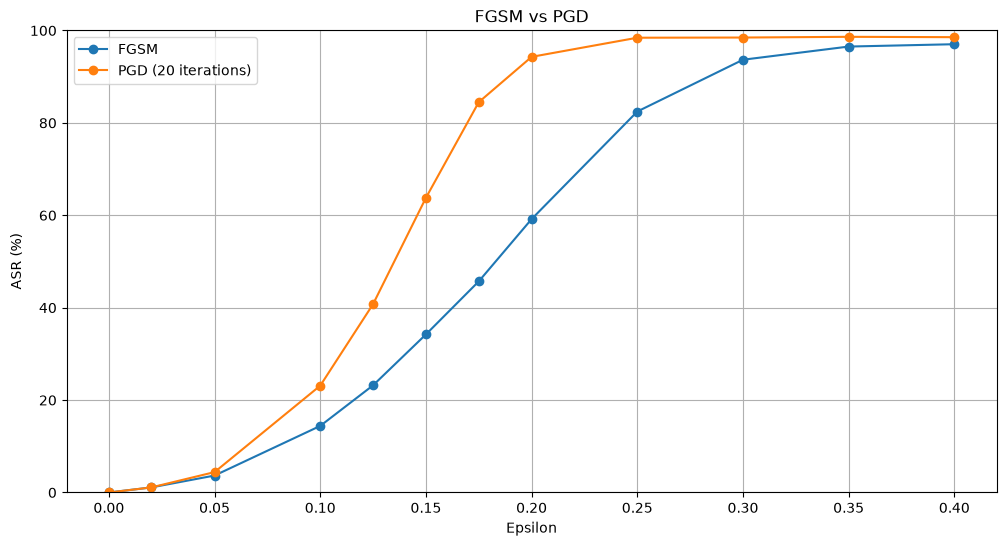

In [11]:
def evaluate_asr(model, loader, attack_fn, criterion, n_batches=10, **attack_kwargs):
    model.eval()

    changed = 0
    total = 0

    for batch_idx, (images, labels) in enumerate(loader):
        if batch_idx >= n_batches:
            break

        images = images.to(device)
        labels = labels.to(device)

        # Исходные предсказания
        with torch.no_grad():
            outputs = model(images)
            original_preds = outputs.argmax(dim=1)

        # Атака
        adv_images = attack_fn(
            model,
            images,
            labels,
            criterion=criterion,
            **attack_kwargs
        )

        # Предсказания после атаки
        with torch.no_grad():
            adv_outputs = model(adv_images)
            adv_preds = adv_outputs.argmax(dim=1)

        # Считаем изменившиеся предсказания
        changed += (original_preds != adv_preds).sum().item()
        total += labels.size(0)

    return 100 * changed / total

epsilons = [
    0.0, 0.02, 0.05, 0.1,
    0.125, 0.15, 0.175, 0.2,
    0.25, 0.3, 0.35, 0.4
]

fgsm_asr = []
pgd20_asr = []

for epsilon in epsilons:

    # FGSM
    asr_fgsm = evaluate_asr(
        model,
        test_loader,
        fgsm_attack,
        crit,
        n_batches=10,
        epsilon=epsilon
    )

    # PGD, 20 итераций
    asr_pgd20 = evaluate_asr(
        model,
        test_loader,
        pgd_attack,
        crit,
        n_batches=10,
        epsilon=epsilon,
        alpha=0.02,
        num_iter=20,
        randomize=True
    )

    fgsm_asr.append(asr_fgsm)
    pgd20_asr.append(asr_pgd20)

plt.figure(figsize=(12, 6))

plt.plot(
    epsilons,
    fgsm_asr,
    marker="o",
    label="FGSM"
)

plt.plot(
    epsilons,
    pgd20_asr,
    marker="o",
    label="PGD (20 iterations)"
)

plt.xlabel("Epsilon")
plt.ylabel("ASR (%)")
plt.title("FGSM vs PGD")
plt.grid(True)
plt.legend()

plt.ylim(0, 100)

plt.show()


### 2.4. Влияние числа итераций PGD

**Задание:** зафиксируйте $\epsilon = 0.15$ и постройте график зависимости ASR от числа итераций PGD $\in \{1, 2, 5, 10, 20, 40, 80\}$. Определите, при каком числе итераций ASR стабилизируется (перестаёт заметно расти).

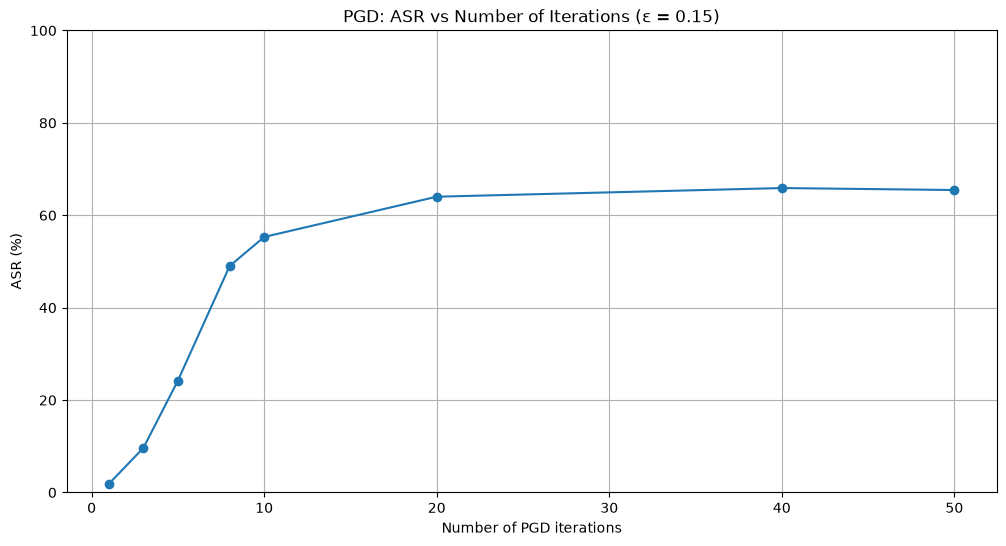

In [12]:
iterations = [1, 3, 5, 8, 10, 20, 40, 50]

pgd_iterations_asr = []

epsilon = 0.15
alpha = 0.02

for num_iter in iterations:
    asr = evaluate_asr(
        model,
        test_loader,
        pgd_attack,
        crit,
        n_batches=10,
        epsilon=epsilon,
        alpha=alpha,
        num_iter=num_iter,
        randomize=True
    )

    pgd_iterations_asr.append(asr)

plt.figure(figsize=(12, 6))

plt.plot(
    iterations,
    pgd_iterations_asr,
    marker="o"
)

plt.xlabel("Number of PGD iterations")
plt.ylabel("ASR (%)")
plt.title("PGD: ASR vs Number of Iterations (ε = 0.15)")

plt.grid(True)
plt.ylim(0, 100)

plt.show()

**Вопрос для отчёта:** при каком числе итераций ASR практически перестаёт расти? Как это соотносится с утверждением лекции о том, что одношаговая линеаризация (FGSM) даёт лишь нижнюю оценку силы атаки?

_Ваш ответ:_ PGD может находить более эффективные возмущения, поскольку на каждом шаге заново вычисляет градиент

### 2.5. Adversarial training через PGD (седловая точка)

**Задание:** обучите вторую модель с adversarial training по формулировке седловой точки Мадри:

$\min_{\theta} \mathbb{E}_{(x,y)}\left[\max_{\delta \in \mathcal{S}} L(\theta, x+\delta, y)\right]$

На каждом шаге обучения внутренний максимум приближайте PGD с небольшим числом итераций (5-7), а внешний шаг оптимизации делайте по параметрам модели на полученных adversarial-примерах.

In [13]:
adv_model = SmallCNN().to(device)

opt_adv = torch.optim.Adam(
    adv_model.parameters(),
    lr=0.001
)

crit_adv = nn.CrossEntropyLoss()

epochs = 3

for epoch in range(epochs):
    adv_model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        # Строим adversarial-примеры через PGD
        x_adv = pgd_attack(
            adv_model,
            images,
            labels,
            epsilon=0.15,
            alpha=0.02,
            num_iter=7,
            criterion=crit_adv,
            randomize=True
        )

        # Обучаем модель на adversarial-примерах
        opt_adv.zero_grad()

        outputs = adv_model(x_adv)
        loss = crit_adv(outputs, labels)

        loss.backward()
        opt_adv.step()

        running_loss += loss.item() * images.size(0)

        predictions = outputs.argmax(dim=1)
        correct += (predictions == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = 100 * correct / total

    print(
        f"Epoch {epoch + 1}/{epochs} | "
        f"Loss: {epoch_loss:.4f} | "
        f"Adversarial accuracy: {epoch_acc:.2f}%"
    )


Epoch 1/3 | Loss: 0.6323 | Adversarial accuracy: 78.93%
Epoch 2/3 | Loss: 0.2890 | Adversarial accuracy: 90.58%
Epoch 3/3 | Loss: 0.2346 | Adversarial accuracy: 92.28%


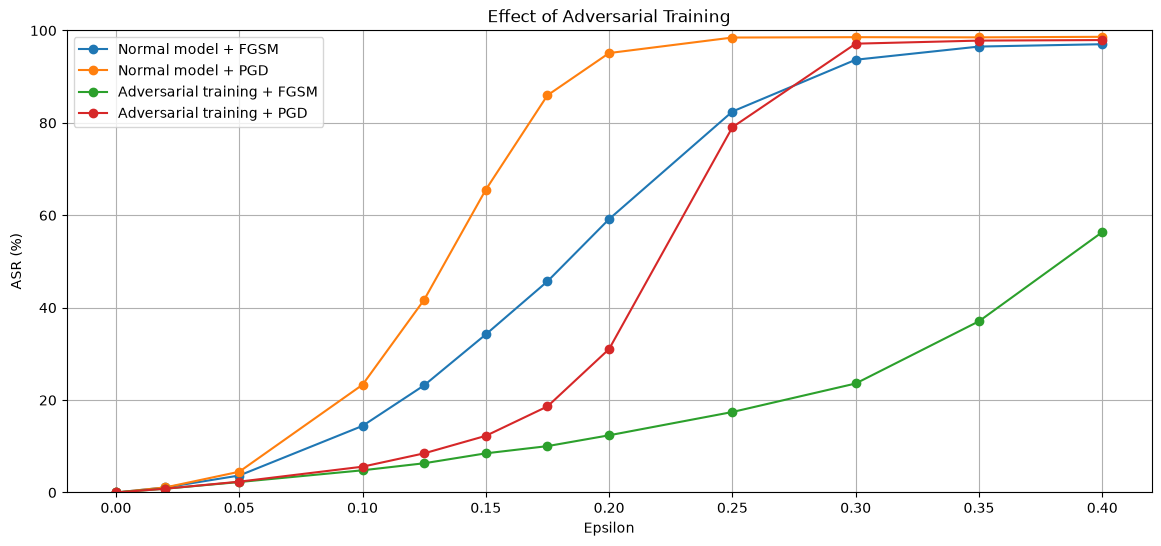

In [14]:
epsilons = [
    0.0, 0.02, 0.05, 0.1,
    0.125, 0.15, 0.175, 0.2,
    0.25, 0.3, 0.35, 0.4
]

# Обычная модель
fgsm_asr_normal = []
pgd_asr_normal = []

# Adversarially trained модель
fgsm_asr_adv = []
pgd_asr_adv = []

for epsilon in epsilons:

    asr = evaluate_asr(
        model,
        test_loader,
        fgsm_attack,
        crit,
        n_batches=10,
        epsilon=epsilon
    )

    fgsm_asr_normal.append(asr)

    asr = evaluate_asr(
        model,
        test_loader,
        pgd_attack,
        crit,
        n_batches=10,
        epsilon=epsilon,
        alpha=0.02,
        num_iter=40,
        randomize=True
    )

    pgd_asr_normal.append(asr)

    asr = evaluate_asr(
        adv_model,
        test_loader,
        fgsm_attack,
        crit_adv,
        n_batches=10,
        epsilon=epsilon
    )

    fgsm_asr_adv.append(asr)

    asr = evaluate_asr(
        adv_model,
        test_loader,
        pgd_attack,
        crit_adv,
        n_batches=10,
        epsilon=epsilon,
        alpha=0.02,
        num_iter=40,
        randomize=True
    )

    pgd_asr_adv.append(asr)

plt.figure(figsize=(14, 6))

plt.plot(
    epsilons,
    fgsm_asr_normal,
    marker="o",
    label="Normal model + FGSM"
)

plt.plot(
    epsilons,
    pgd_asr_normal,
    marker="o",
    label="Normal model + PGD"
)

plt.plot(
    epsilons,
    fgsm_asr_adv,
    marker="o",
    label="Adversarial training + FGSM"
)

plt.plot(
    epsilons,
    pgd_asr_adv,
    marker="o",
    label="Adversarial training + PGD"
)

plt.xlabel("Epsilon")
plt.ylabel("ASR (%)")
plt.title("Effect of Adversarial Training")

plt.grid(True)
plt.legend()
plt.ylim(0, 100)

plt.show()


**Вопрос для отчёта:** насколько снизился ASR против PGD и против FGSM после adversarial training? Согласуется ли результат с идеей «универсального первопорядкового противника» — устойчивость к PGD переносится на устойчивость к более слабым атакам?

_Ваш ответ:_ После adversarial training существенно снизился ASR для обоих типов атак. По графикам видно, что устойчивость к PGD переносится на устойчивость к FGSM

## Часть III. Атака Carlini & Wagner (C&W)

### 3.1. Реализация целевой C&W L2-атаки

**Задание:** реализуйте C&W-атаку (вариант L2, целевая) по следующей схеме:

1. Замена переменных: $ x' = \frac{1}{2}\tanh(w)+1) $ — гарантирует $x' \in [0,1]$ без явного clipping.
2. Функция потерь на логитах с параметром confidence κ:
$ f(x') = \max\left( \max_{i \ne t} Z(x')_i - Z(x')_t,\; -\kappa \right) $
3. Итоговая целевая функция:
 
$ \min_{w} \left\| \tfrac{1}{2}(\tanh(w)+1) - x \right\|_2^2 + c \cdot f\left(\tfrac{1}{2}(\tanh(w)+1)\right) $

4. Оптимизация через Adam по переменной $w$.

In [15]:
def cw_l2_attack(model, x, target_class, c=1.0, kappa=0.0, num_steps=200, lr=0.01):
    # 1. Инициализируем w через исходное изображение
    x_clamped = torch.clamp(x, 1e-6, 1 - 1e-6) # Чтобы atanh не ушел в бесконечность

    w = torch.atanh(2 * x_clamped - 1)
    w = w.clone().detach().requires_grad_(True)

    # 2. Оптимизатор Adam по переменной w
    optimizer = torch.optim.Adam([w], lr=lr)

    for _ in range(num_steps):

        # 3. Получаем adversarial image из w
        x_adv = 0.5 * (torch.tanh(w) + 1)

        # Логиты модели
        logits = model(x_adv)

        # Логит целевого класса
        target_logit = logits[:, target_class]

        # Максимальный логит среди остальных классов
        other_logits = logits.clone()
        other_logits[:, target_class] = float("-inf")

        max_other_logit = other_logits.max(dim=1).values

        # f(x') = max(max_other - target, -kappa)
        f_loss = torch.clamp(
            max_other_logit - target_logit,
            min=-kappa
        )

        # L2 норма
        dist_loss = torch.sum(
            (x_adv - x) ** 2,
            dim=(1, 2, 3)
        )

        # Итоговая функция потерь
        loss = dist_loss + c * f_loss

        # Среднее по batch
        loss = loss.mean()

        # Обновляем w
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    # Финальное adversarial image
    x_adv = 0.5 * (torch.tanh(w) + 1)

    return x_adv.detach()


### 3.2. Демонстрация целевой атаки

**Задание:** выберите тестовый пример и целевой класс (отличный от истинного), постройте adversarial-пример методом C&W (κ=0) и визуализируйте: оригинал, возмущение (с указанием L2-нормы), adversarial-пример (с предсказанием и confidence).

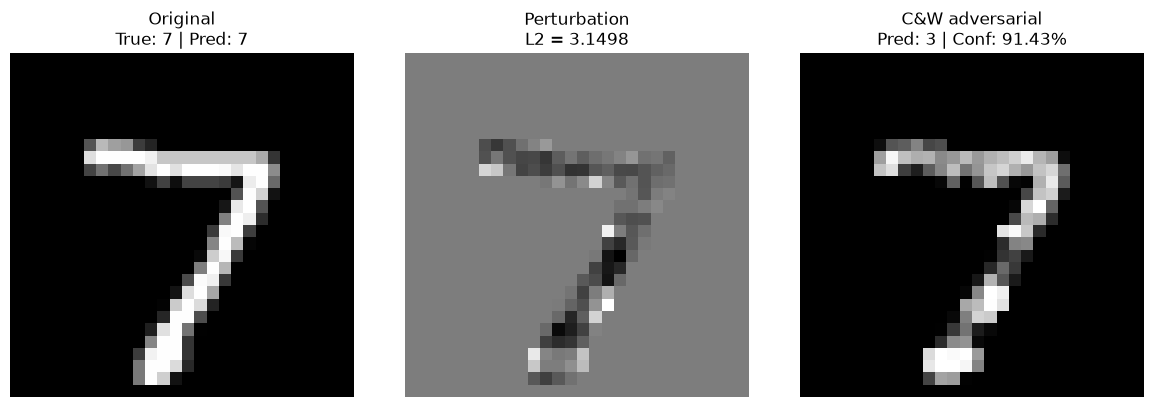

In [28]:
images, labels = next(iter(test_loader))

image = images[0:1].to(device)
label = labels[0:1].to(device)

# Целевой класс
target_class = 3

# C&W L2 атака
cw_image = cw_l2_attack(
    model,
    image,
    target_class=target_class,
    c=2.0,
    kappa=2.5,
    num_steps=200,
    lr=0.01
)

# Получаем предсказания и confidence
model.eval()

with torch.no_grad():
    original_logits = model(image)
    cw_logits = model(cw_image)

    original_pred = original_logits.argmax(dim=1).item()
    cw_pred = cw_logits.argmax(dim=1).item()

    cw_probs = torch.softmax(cw_logits, dim=1)
    cw_confidence = cw_probs[0, cw_pred].item()

# Возмущение
perturbation = cw_image - image

# L2-норма возмущения
l2_norm = torch.norm(
    perturbation.reshape(-1),
    p=2
).item()

# Визуализация
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

# Оригинал
axes[0].imshow(
    image.squeeze().cpu().numpy(),
    cmap="gray"
)
axes[0].set_title(
    f"Original\nTrue: {label.item()} | Pred: {original_pred}"
)
axes[0].axis("off")

# Возмущение
axes[1].imshow(
    perturbation.squeeze().cpu().numpy(),
    cmap="gray"
)
axes[1].set_title(
    f"Perturbation\nL2 = {l2_norm:.4f}"
)
axes[1].axis("off")

# Adversarial image
axes[2].imshow(
    cw_image.squeeze().cpu().numpy(),
    cmap="gray"
)
axes[2].set_title(
    f"C&W adversarial\nPred: {cw_pred} | Conf: {cw_confidence:.2%}"
)
axes[2].axis("off")

plt.tight_layout()
plt.show()

### 3.3. Влияние параметра confidence κ

**Задание:** для того же примера постройте C&W-атаки с κ ∈ {0, 5, 10, 20, 40} и постройте два графика: (а) зависимость L2-нормы возмущения от κ, (б) зависимость вероятности целевого класса от κ.

In [24]:
# Значения confidence kappa
kappas = [0, 1, 3, 5, 8, 10, 15, 20]

l2_norms = []
target_confidences = []

for kappa in kappas:
    # C&W атака
    cw_image = cw_l2_attack(
        model,
        image,
        target_class=target_class,
        c=2.0,
        kappa=kappa,
        num_steps=200,
        lr=0.01
    )

    # Возмущение
    perturbation = cw_image - image

    # L2-норма
    l2_norm = torch.norm(
        perturbation.reshape(-1),
        p=2
    ).item()

    # Предсказание и confidence
    with torch.no_grad():
        logits = model(cw_image)
        probs = torch.softmax(logits, dim=1)

        pred = logits.argmax(dim=1).item()
        target_confidence = probs[0, target_class].item()

    l2_norms.append(l2_norm)
    target_confidences.append(target_confidence)

    print(
        f"kappa={kappa:2d} | "
        f"Pred={pred} | "
        f"Target confidence={target_confidence:.4f} | "
        f"L2={l2_norm:.4f}"
    )

kappa= 0 | Pred=3 | Target confidence=0.4951 | L2=2.7679
kappa= 1 | Pred=3 | Target confidence=0.7182 | L2=2.9229
kappa= 3 | Pred=3 | Target confidence=0.9468 | L2=3.2448
kappa= 5 | Pred=3 | Target confidence=0.9897 | L2=3.5992
kappa= 8 | Pred=3 | Target confidence=0.9949 | L2=3.8015
kappa=10 | Pred=3 | Target confidence=0.9949 | L2=3.8015
kappa=15 | Pred=3 | Target confidence=0.9949 | L2=3.8015
kappa=20 | Pred=3 | Target confidence=0.9949 | L2=3.8015


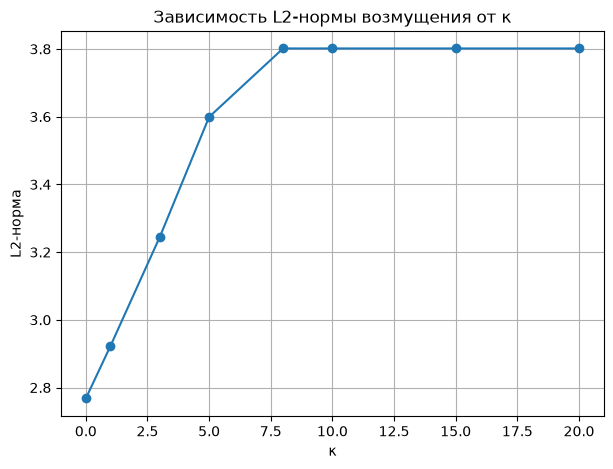

In [25]:
plt.figure(figsize=(7, 5))

plt.plot(
    kappas,
    l2_norms,
    marker="o"
)

plt.xlabel("κ")
plt.ylabel("L2-норма")
plt.title("Зависимость L2-нормы возмущения от κ")
plt.grid(True)

plt.show()

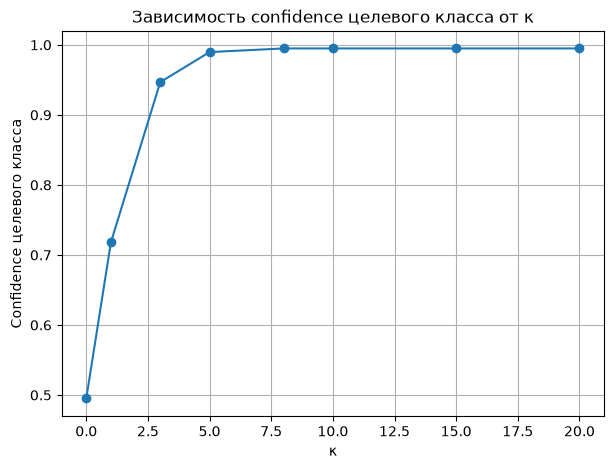

In [26]:
plt.figure(figsize=(7, 5))

plt.plot(
    kappas,
    target_confidences,
    marker="o"
)

plt.xlabel("κ")
plt.ylabel("Confidence целевого класса")
plt.title("Зависимость confidence целевого класса от κ")
plt.grid(True)

plt.show()

**Вопрос для отчёта:** как изменяется величина возмущения при росте κ? Объясните этот эффект, опираясь на формулу функции потерь $f(x')$ из лекции.

_Ваш ответ:_ При увеличении κ величина возмущения возрастает. Это связано с тем, что C&W требует не просто сделать целевой класс победителем, а обеспечить ему больший запас по логитам.

## Часть IV. Jacobian-based Saliency Map Attack (JSMA)

### 4.1. Реализация JSMA

**Задание:** реализуйте целевую JSMA-атаку по следующей схеме:

1. Вычислите якобиан выходных вероятностей модели по входу (для всех 10 классов).
2. Постройте saliency-карту: произведение градиента целевого класса и (с обратным знаком) суммарного градиента остальных классов, отбирая только те пиксели, где рост значения пикселя увеличивает вероятность целевого класса и одновременно уменьшает вероятность остальных.
3. На каждой итерации выберите пиксель с максимальной saliency, "насытите" его значение (увеличьте до предела, например, на величину θ=1.0), исключите уже изменённые и предельные пиксели из дальнейшего рассмотрения.
4. Повторяйте, пока не будет достигнута целевая классификация или не будет исчерпан лимит `max_pixels`.

In [ ]:
# Вычисление якобиана
def compute_jacobian(model, x, num_classes=10):
    x = x.clone().detach().requires_grad_(True)

    logits = model(x)
    probs = torch.softmax(logits, dim=1)

    jacobian = []

    for c in range(num_classes):
        grad_outputs = torch.zeros_like(probs)
        grad_outputs[:, c] = 1.0

        grad = torch.autograd.grad(
            outputs=probs,
            inputs=x,
            grad_outputs=grad_outputs,
            retain_graph=True
        )[0]

        jacobian.append(grad[0])

    jacobian = torch.stack(jacobian, dim=0)

    return jacobian


In [30]:
def jsma_attack(model, x, target_class, max_pixels=60, theta=1.0):
    model.eval()

    x_adv = x.clone().detach()

    # Маска уже изменённых пикселей
    modified = torch.zeros_like(
        x_adv[0],
        dtype=torch.bool
    )

    num_modified = 0

    for _ in range(max_pixels):

        # Проверяем текущее предсказание
        with torch.no_grad():
            output = model(x_adv)
            prediction = output.argmax(dim=1).item()

        # Если уже достигли target — заканчиваем
        if prediction == target_class:
            break

        # Вычисляем якобиан
        jacobian = compute_jacobian(
            model,
            x_adv
        )

        # Градиент целевого класса
        target_grad = jacobian[target_class]

        # Сумма градиентов остальных классов
        other_classes = [
            c for c in range(10)
            if c != target_class
        ]

        other_grad = jacobian[other_classes].sum(dim=0)

        # Saliency map
        saliency = (
            target_grad
            * (other_grad < 0)
            * torch.abs(other_grad)
        )

        # Убираем уже изменённые пиксели
        saliency = saliency.clone()
        saliency[modified] = float("-inf")

        # Убираем насыщенные пиксели
        saturated = x_adv[0] >= 0.99
        saliency[saturated] = float("-inf")

        # Выбираем пиксель с максимальной saliency
        flat_index = torch.argmax(
            saliency.reshape(-1)
        )

        # Если подходящих пикселей больше нет
        if torch.isinf(saliency.reshape(-1)[flat_index]):
            break

        # Преобразуем индекс обратно в координаты
        pixel_index = torch.unravel_index(
            flat_index,
            saliency.shape
        )

        # Увеличиваем значение пикселя
        x_adv[
            0,
            pixel_index[0],
            pixel_index[1],
            pixel_index[2]
        ] = torch.clamp(
            x_adv[
                0,
                pixel_index[0],
                pixel_index[1],
                pixel_index[2]
            ] + theta,
            0,
            1
        )

        # Отмечаем пиксель как изменённый
        modified[pixel_index] = True

        num_modified += 1

    return x_adv.detach(), num_modified


### 4.2. Демонстрация точечной атаки

**Задание:** для того же примера и целевого класса, что и в п.3.2, постройте JSMA-атаку и визуализируйте: оригинал, карту изменённых пикселей, adversarial-пример (с предсказанием модели и числом изменённых пикселей).

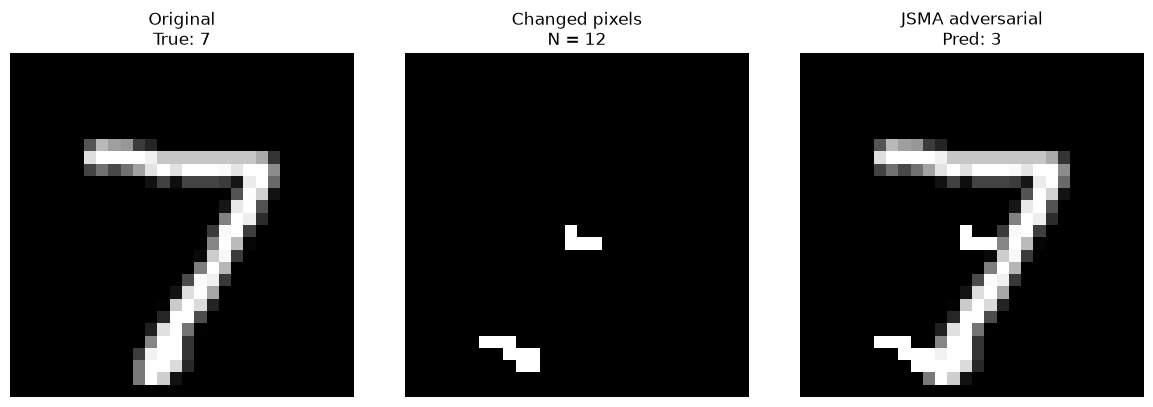

In [33]:
# JSMA-атака для того же примера и target_class
jsma_image, num_modified = jsma_attack(
    model,
    image,
    target_class=target_class,
    max_pixels=60,
    theta=1.0
)

# Предсказание adversarial-примера
model.eval()

with torch.no_grad():
    logits = model(jsma_image)
    jsma_pred = logits.argmax(dim=1).item()

# Маска изменённых пикселей
changed_pixels = (
    torch.abs(jsma_image - image) > 1e-6
).float()

# Визуализация
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

# 1. Оригинал
axes[0].imshow(
    image.squeeze().cpu().numpy(),
    cmap="gray"
)
axes[0].set_title(
    f"Original\nTrue: {label.item()}"
)
axes[0].axis("off")

# 2. Карта изменённых пикселей
axes[1].imshow(
    changed_pixels.squeeze().cpu().numpy(),
    cmap="gray"
)
axes[1].set_title(
    f"Changed pixels\nN = {num_modified}"
)
axes[1].axis("off")

# 3. Adversarial
axes[2].imshow(
    jsma_image.squeeze().cpu().numpy(),
    cmap="gray"
)
axes[2].set_title(
    f"JSMA adversarial\nPred: {jsma_pred}"
)
axes[2].axis("off")

plt.tight_layout()
plt.show()

**Вопрос для отчёта:** сколько пикселей потребовалось изменить для успешной атаки? Насколько это число мало по сравнению с общим числом пикселей изображения (28×28=784)?

_Ваш ответ:_ Всего потребовалось поменять 12 пикселей - 1.5% от общего количества

## Часть V. Итоговое сравнение атак

**Задание:** для одного и того же исходного изображения и целевого класса постройте атаки всеми тремя методами (целевой PGD, C&W, JSMA) и сравните их в таблице по следующим критериям:
- успешность (достигнут ли целевой класс);
- L2-норма возмущения;
- L∞-норма возмущения;
- число изменённых пикселей (порог изменения > 1e-3).

Постройте также столбчатую диаграмму, сравнивающую три атаки по каждому из трёх числовых критериев.

In [34]:
def pgd_targeted(model, x, target, epsilon, alpha, num_iter, criterion):
    # Начинаем с исходного изображения
    x_adv = x.clone().detach()

    for _ in range(num_iter):
        x_adv.requires_grad_(True)

        # Предсказание модели
        outputs = model(x_adv)

        # Loss относительно целевого класса
        loss = criterion(outputs, target)

        model.zero_grad()
        loss.backward()

        # Для targeted PGD минимизируем loss
        x_adv = x_adv - alpha * x_adv.grad.sign()

        # Ограничиваем возмущение в epsilon
        delta = torch.clamp(
            x_adv - x,
            -epsilon,
            epsilon
        )

        # Ограничиваем значения изображения [0, 1]
        x_adv = torch.clamp(
            x + delta,
            0,
            1
        ).detach()

    return x_adv

In [35]:
def calculate_metrics(x, x_adv):
    perturbation = x_adv - x

    l2 = torch.norm(
        perturbation.reshape(-1),
        p=2
    ).item()

    linf = torch.norm(
        perturbation.reshape(-1),
        p=float("inf")
    ).item()

    num_pixels = (
        torch.abs(perturbation) > 1e-3
    ).sum().item()

    return l2, linf, num_pixels

In [38]:
# Исходное изображение и целевой класс
target = torch.tensor(
    [target_class],
    device=device
)

criterion = nn.CrossEntropyLoss()

# --------------------------------------------------
# 1. Targeted PGD
# --------------------------------------------------

pgd_image = pgd_targeted(
    model,
    image,
    target,
    epsilon=0.2,
    alpha=0.02,
    num_iter=40,
    criterion=criterion
)

# --------------------------------------------------
# 2. C&W
# --------------------------------------------------

cw_image = cw_l2_attack(
    model,
    image,
    target_class=target_class,
    c=2.0,
    kappa=0.0,
    num_steps=200,
    lr=0.01
)

# --------------------------------------------------
# 3. JSMA
# --------------------------------------------------

jsma_image, jsma_num_modified = jsma_attack(
    model,
    image,
    target_class=target_class,
    max_pixels=60,
    theta=1.0
)
attacks = {
    "Targeted PGD": pgd_image,
    "C&W": cw_image,
    "JSMA": jsma_image
}

results = []

model.eval()

for method, adv_image in attacks.items():

    with torch.no_grad():
        logits = model(adv_image)
        prediction = logits.argmax(dim=1).item()

    success = prediction == target_class

    l2, linf, num_pixels = calculate_metrics(
        image,
        adv_image
    )

    results.append({
        "Метод": method,
        "Успех": success,
        "Предсказание": prediction,
        "L2": l2,
        "Linf": linf,
        "Число пикселей": num_pixels
    })

results_df = pd.DataFrame(results)

display(results_df)

results_df.to_csv(
    "attack_comparison.csv",
    index=False
)

,Метод,Успех,Предсказание,L2,Linf,Число пикселей
0,Targeted PGD,True,3,3.982432,0.200000,503
1,C&W,True,3,2.767924,0.644156,115
2,JSMA,True,3,3.294683,1.000000,12


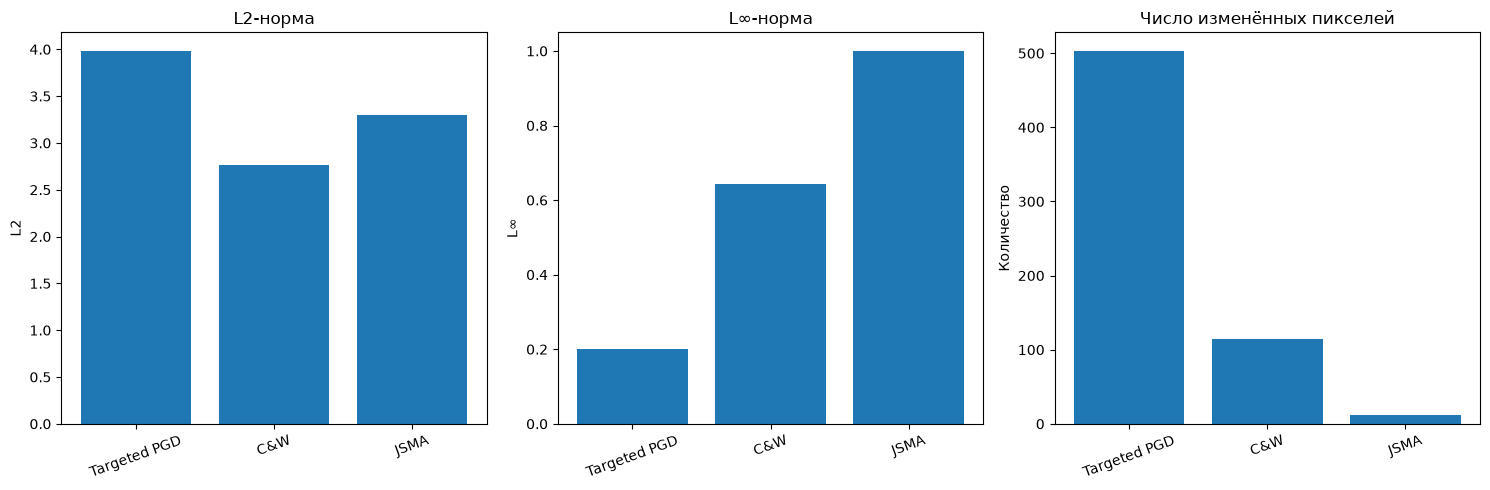

In [39]:
methods = results_df["Метод"]

fig, axes = plt.subplots(
    1,
    3,
    figsize=(15, 5)
)

# L2
axes[0].bar(
    methods,
    results_df["L2"]
)

axes[0].set_title("L2-норма")
axes[0].set_ylabel("L2")
axes[0].tick_params(axis="x", rotation=20)

# Linf
axes[1].bar(
    methods,
    results_df["Linf"]
)

axes[1].set_title("L∞-норма")
axes[1].set_ylabel("L∞")
axes[1].tick_params(axis="x", rotation=20)

# Число пикселей
axes[2].bar(
    methods,
    results_df["Число пикселей"]
)

axes[2].set_title("Число изменённых пикселей")
axes[2].set_ylabel("Количество")
axes[2].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()


**Вопрос для отчёта:** какой метод дал наименьшую L2-норму возмущения? Какой — наименьшее число изменённых пикселей? Объясните разницу, опираясь на то, какую норму возмущения оптимизирует каждый метод по своей природе.

_Ваш ответ:_ 

## Часть VI. Итоговый вывод

**Вопрос для отчёта:** сформулируйте общий вывод о трёх изученных методах атак. Почему PGD считается «универсальным первопорядковым противником» и стандартом для adversarial training, тогда как C&W чаще используется как эталон для проверки устойчивости защитных механизмов, а JSMA — как инструмент, ценный своей интерпретируемостью и разреженностью возмущения? В каких прикладных сценариях (например, атаки на изображения высокого разрешения, на табличные данные, на системы обнаружения вторжений) предпочтителен каждый из методов?

_Ваш ответ:_ 
PGD — универсальная и достаточно сильная первопорядковая атака, поэтому широко используется как стандарт для adversarial training и проверки устойчивости моделей.

C&W хорошо подходит для оценки защищённости, так как ищет малое возмущение, необходимое для успешной атаки, поэтому часто используется как эталонный метод.

JSMA отличается разреженностью: изменяет небольшое количество наиболее важных признаков, поэтому ценен своей интерпретируемостью.

---
Выполните **не менее двух** из следующих заданий. Оформите результаты в отдельных ячейках ниже с пометкой `# ДЛЯ СИЛЬНЫХ СТУДЕНТОВ`.

### С1. PGD с разными нормами
Реализуйте вариант PGD-атаки с проекцией на $L_2$-шар вместо $L_\infty$ (нормализация градиента по L2-норме на каждом шаге с последующим масштабированием под бюджет ε). Сравните визуально и по ASR с исходным $L_\infty$-вариантом.

### С2. Ускоренная (Maximal) JSMA
Изучите идею ускоренных версий JSMA (например, приближение сложности с $O(M^2 N)$ до $O(M\sqrt{N})$ за счёт эвристического отбора кандидатов вместо полного перебора). Реализуйте упрощённую версию с случайной подвыборкой кандидатов на каждой итерации и сравните скорость и качество атаки с полной версией из Части IV.

### С3. Перенос устойчивости между атаками (adversarial training cross-attack)
Обучите модель с adversarial training на PGD (Часть 2.5). Проверьте её устойчивость не только к PGD и FGSM, но и к C&W и JSMA. Обсудите, перенеслась ли устойчивость на оптимизационные и разреженные атаки, которые не участвовали в обучении.

### С4. Влияние константы c в C&W
Исследуйте, как выбор константы $c$ в целевой функции C&W (без бинарного поиска, вручную для нескольких значений: 0.1, 1, 10, 100) влияет на баланс между успешностью атаки и величиной L2-искажения. Постройте график Success Rate и средней L2-нормы в зависимости от $c$ на нескольких тестовых примерах.


## C1
PGD с L2 нормой

In [42]:
def pgd_l2_attack(model, x, y, epsilon, alpha, num_iter, criterion, randomize=True):
    # Начальное возмущение
    if randomize:
        delta = torch.randn_like(x)

        # Нормализуем случайное направление
        delta_norm = torch.norm(
            delta.reshape(delta.size(0), -1),
            p=2,
            dim=1,
            keepdim=True
        )

        delta = delta / (delta_norm.view(-1, 1, 1, 1) + 1e-12)

        # Случайный радиус внутри L2-шара
        radius = torch.rand(
            x.size(0),
            device=x.device
        )

        delta = delta * (
            radius * epsilon
        ).view(-1, 1, 1, 1)

        delta = torch.clamp(
            x + delta,
            0,
            1
        ) - x
    else:
        delta = torch.zeros_like(x)

    delta = delta.detach()

    for _ in range(num_iter):
        delta.requires_grad_(True)

        outputs = model(x + delta)
        loss = criterion(outputs, y)

        model.zero_grad()
        loss.backward()

        # L2-нормализация градиента
        grad = delta.grad

        grad_norm = torch.norm(
            grad.reshape(grad.size(0), -1),
            p=2,
            dim=1,
            keepdim=True
        )

        normalized_grad = grad / (
            grad_norm.view(-1, 1, 1, 1) + 1e-12
        )

        # Шаг по направлению градиента
        delta = delta + alpha * normalized_grad

        # Проекция на L2-шар
        delta_flat = delta.reshape(
            delta.size(0),
            -1
        )

        delta_norm = torch.norm(
            delta_flat,
            p=2,
            dim=1,
            keepdim=True
        )

        scale = torch.clamp(
            epsilon / (delta_norm + 1e-12),
            max=1.0
        )

        delta = (
            delta_flat * scale
        ).reshape_as(delta)

        # Ограничение изображения [0, 1]
        delta = torch.clamp(
            x + delta,
            0,
            1
        ) - x

        delta = delta.detach()

    return torch.clamp(x + delta, 0, 1)

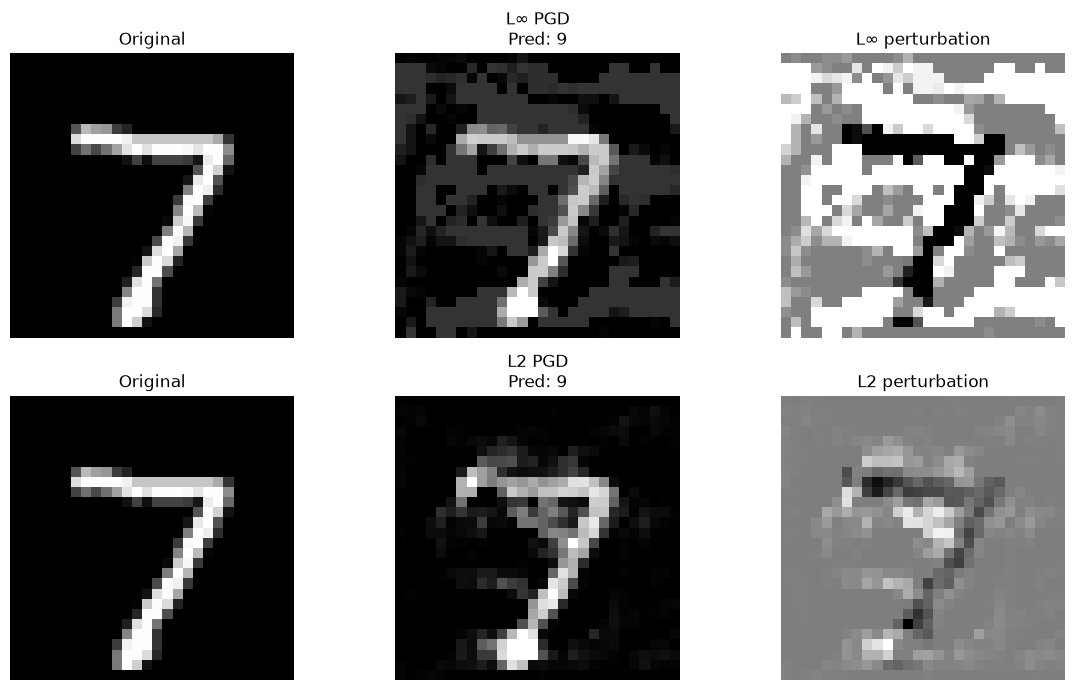

In [44]:
criterion = nn.CrossEntropyLoss()

# Обычный L_inf PGD
pgd_linf_image = pgd_attack(
    model,
    image,
    label,
    epsilon=0.2,
    alpha=0.02,
    num_iter=40,
    criterion=criterion,
    randomize=True
)

# L2 PGD
pgd_l2_image = pgd_l2_attack(
    model,
    image,
    label,
    epsilon=3.0,
    alpha=0.2,
    num_iter=40,
    criterion=criterion,
    randomize=True
)

with torch.no_grad():
    original_pred = model(image).argmax(dim=1).item()
    linf_pred = model(pgd_linf_image).argmax(dim=1).item()
    l2_pred = model(pgd_l2_image).argmax(dim=1).item()

linf_success = original_pred != linf_pred
l2_success = original_pred != l2_pred

linf_perturbation = pgd_linf_image - image
l2_perturbation = pgd_l2_image - image

fig, axes = plt.subplots(2, 3, figsize=(12, 7))

axes[0, 0].imshow(
    image.squeeze().cpu().numpy(),
    cmap="gray"
)
axes[0, 0].set_title("Original")
axes[0, 0].axis("off")

axes[0, 1].imshow(
    pgd_linf_image.squeeze().cpu().numpy(),
    cmap="gray"
)
axes[0, 1].set_title(
    f"L∞ PGD\nPred: {linf_pred}"
)
axes[0, 1].axis("off")

axes[0, 2].imshow(
    linf_perturbation.squeeze().cpu().numpy(),
    cmap="gray"
)
axes[0, 2].set_title("L∞ perturbation")
axes[0, 2].axis("off")

axes[1, 0].imshow(
    image.squeeze().cpu().numpy(),
    cmap="gray"
)
axes[1, 0].set_title("Original")
axes[1, 0].axis("off")

axes[1, 1].imshow(
    pgd_l2_image.squeeze().cpu().numpy(),
    cmap="gray"
)
axes[1, 1].set_title(
    f"L2 PGD\nPred: {l2_pred}"
)
axes[1, 1].axis("off")

axes[1, 2].imshow(
    l2_perturbation.squeeze().cpu().numpy(),
    cmap="gray"
)
axes[1, 2].set_title("L2 perturbation")
axes[1, 2].axis("off")

plt.tight_layout()
plt.show()

При Linf-PGD ограничивается максимальное изменение отдельного пикселя, поэтому возмущение распределяется по изображению более равномерно. В L2-PGD ограничивается общая величина возмущения, поэтому модель может сильнее изменять отдельные пиксели, сохраняя заданный общий L2-бюджет. Поэтому визуальный вид атак и их ASR могут отличаться.

## C4
Константа c в C&W

In [46]:
c_values = [0.1, 0.5, 1, 2, 5, 10, 20, 50]

n_samples = 20

selected_images = []
selected_labels = []

for images, labels in test_loader:
    for i in range(len(labels)):
        if labels[i].item() != 3:
            selected_images.append(images[i:i+1])
            selected_labels.append(labels[i].item())

        if len(selected_images) >= n_samples:
            break

    if len(selected_images) >= n_samples:
        break


In [48]:
cw_results = []

for c in c_values:

    successes = 0
    l2_values = []

    for image_i, true_label in zip(
        selected_images,
        selected_labels
    ):
        image_i = image_i.to(device)

        target = 3

        adv_image = cw_l2_attack(
            model,
            image_i,
            target_class=target,
            c=c,
            kappa=0.0,
            num_steps=200,
            lr=0.01
        )

        with torch.no_grad():
            prediction = model(
                adv_image
            ).argmax(dim=1).item()

        success = prediction == target

        if success:
            successes += 1

        # L2-норма
        perturbation = adv_image - image_i

        l2 = torch.norm(
            perturbation.reshape(-1),
            p=2
        ).item()

        l2_values.append(l2)

    success_rate = (
        100 * successes / len(selected_images)
    )

    mean_l2 = np.mean(l2_values)

    cw_results.append({
        "c": c,
        "Success Rate": success_rate,
        "Mean L2": mean_l2
    })

cw_results_df = pd.DataFrame(cw_results)

cw_results_df

,c,Success Rate,Mean L2
0,0.1,0.0,0.233367
1,0.5,0.0,1.190458
2,1.0,10.0,2.268698
3,2.0,65.0,2.651676
4,5.0,65.0,2.950292
5,10.0,90.0,3.178136
6,20.0,95.0,3.443451
7,50.0,95.0,3.699288


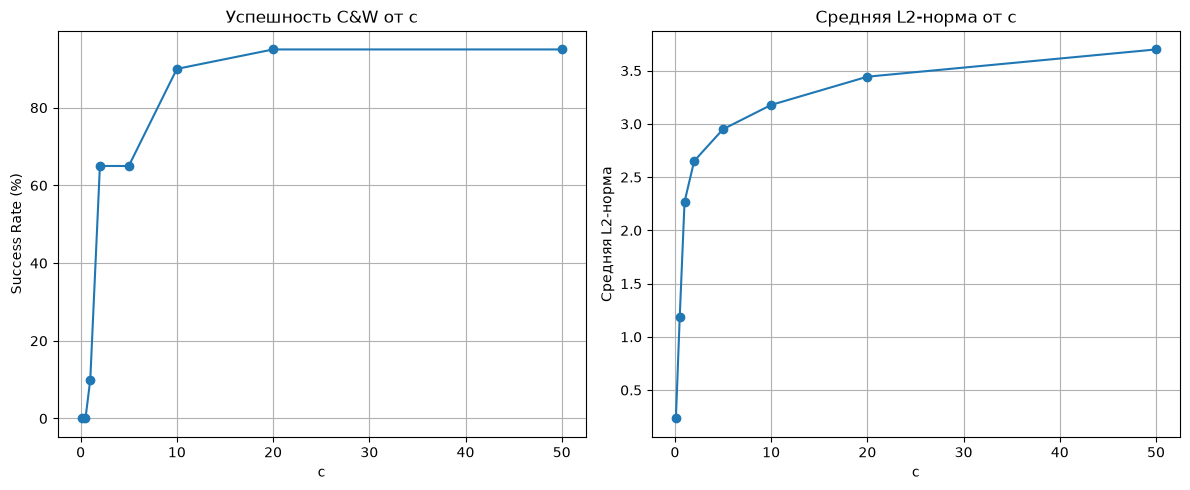

In [50]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(12, 5)
)

# Success Rate
axes[0].plot(
    cw_results_df["c"],
    cw_results_df["Success Rate"],
    marker="o"
)

axes[0].set_xlabel("c")
axes[0].set_ylabel("Success Rate (%)")
axes[0].set_title("Успешность C&W от c")
axes[0].grid(True)

# Mean L2
axes[1].plot(
    cw_results_df["c"],
    cw_results_df["Mean L2"],
    marker="o"
)

axes[1].set_xlabel("c")
axes[1].set_ylabel("Средняя L2-норма")
axes[1].set_title("Средняя L2-норма от c")
axes[1].grid(True)

plt.tight_layout()
plt.show()

При увеличении c целевая часть функции потерь C&W получает больший вес. Поэтому атака сильнее стремится перевести модель в заданный целевой класс, что обычно повышает Success Rate. При этом сохранение близости к исходному изображению становится менее приоритетным, поэтому L2-искажение может увеличиваться. Оптимальное значение c представляет компромисс между успешностью атаки и величиной возмущения.

---

## Требования к сдаче
- Ноутбук выполняется целиком без ошибок (Kernel → Restart & Run All).
- Все `# TODO` заполнены, все вопросы для отчёта содержат письменный ответ.
- Обязательны: реализация PGD с проекцией, реализация C&W с замерами κ, реализация JSMA на основе якобиана, итоговая сравнительная таблица трёх атак.
